In [1]:
# ========== 直接读取增强数据并训练 Transformer ==========

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

# ========== 重新导入公共路径 ROOT ==========

sys.path.append(str(Path("../00_common").resolve()))
from base_path import ROOT

# ========== 重新定义路径 ==========

# 原 Stacking 实验的输出目录
path = ROOT / "02 Stacking" / "t+3"

# 已保存的增强后数据
augmented_file_path = path / "final0.7_augmented.csv"

print("ROOT =", ROOT)
print("实验目录 =", path)
print("增强数据路径 =", augmented_file_path)
print("增强数据是否存在：", augmented_file_path.exists())

ROOT = /home/wei/Data/light
实验目录 = /home/wei/Data/light/02 Stacking/t+3
增强数据路径 = /home/wei/Data/light/02 Stacking/t+3/final0.7_augmented.csv
增强数据是否存在： True


In [2]:


# ========== 1. 读取已经保存好的增强数据 ==========

augmented_file_path = path / "final0.7_augmented.csv"

augmented_data = pd.read_csv(augmented_file_path)

sensor_columns = [col for col in augmented_data.columns if col != "target"]

X_resampled = augmented_data[sensor_columns].values.astype(np.float32)
y_resampled = augmented_data["target"].values.astype(np.float32)

print("读取增强数据：", augmented_file_path)
print("增强数据形状：", augmented_data.shape)
print("X_resampled 形状：", X_resampled.shape)
print("y_resampled 形状：", y_resampled.shape)



读取增强数据： /home/wei/Data/light/02 Stacking/t+3/final0.7_augmented.csv
增强数据形状： (31362, 1381)
X_resampled 形状： (31362, 1380)
y_resampled 形状： (31362,)


In [3]:

# ========== 2. Transformer 输入格式转换 ==========

# 原始 X_resampled: [样本数, 特征数]
# Transformer 输入: [样本数, 特征数, 1]
X_resampled = X_resampled[:, :, np.newaxis]

print("Transformer 输入形状：", X_resampled.shape)



Transformer 输入形状： (31362, 1380, 1)


In [4]:


# ========== 3. 划分训练集和测试集 ==========

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("训练集 X 形状：", X_train.shape)
print("测试集 X 形状：", X_test.shape)
print("训练集 y 形状：", y_train.shape)
print("测试集 y 形状：", y_test.shape)


训练集 X 形状： (25089, 1380, 1)
测试集 X 形状： (6273, 1380, 1)
训练集 y 形状： (25089,)
测试集 y 形状： (6273,)


In [5]:


# ========== 4. 构建 Dataset ==========

class SensorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SensorDataset(X_train, y_train)
test_dataset = SensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=False
)



In [6]:


# ========== 5. 定义 Transformer 回归模型 ==========

class TransformerRegressor(nn.Module):
    def __init__(
        self,
        input_dim=1,
        d_model=64,
        nhead=4,
        num_layers=3,
        dim_feedforward=128,
        dropout=0.1
    ):
        super(TransformerRegressor, self).__init__()

        self.input_embedding = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: [batch_size, feature_num, 1]

        x = self.input_embedding(x)
        x = self.transformer_encoder(x)

        # 对所有特征 token 做平均池化
        x = x.mean(dim=1)

        out = self.regressor(x)

        return out.squeeze(-1)


In [7]:


# ========== 6. 初始化模型 ==========

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前使用设备：", device)

model = TransformerRegressor(
    input_dim=1,
    d_model=64,
    nhead=4,
    num_layers=3,
    dim_feedforward=128,
    dropout=0.1
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)


当前使用设备： cuda


In [8]:


# ========== 7. 训练 Transformer ==========

epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        preds = model(batch_X)
        loss = criterion(preds, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss = epoch_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss:.6f}")



Epoch [10/100], Loss: 96.041484
Epoch [20/100], Loss: 96.041414
Epoch [30/100], Loss: 96.040573
Epoch [40/100], Loss: 96.040144
Epoch [50/100], Loss: 96.039994
Epoch [60/100], Loss: 96.039932
Epoch [70/100], Loss: 96.039875
Epoch [80/100], Loss: 96.039848
Epoch [90/100], Loss: 96.039838
Epoch [100/100], Loss: 96.039828


In [9]:

# ========== 8. 测试集预测 ==========

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        preds = model(batch_X)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.numpy())

y_pred = np.array(all_preds)
y_test = np.array(all_targets)



In [11]:

# ========== 9. 评估 ==========

mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")


# 极端值样本评估
extreme_samples = np.abs(y_test) > 10

if extreme_samples.sum() > 0:
    extreme_mse = mean_squared_error(
        y_test[extreme_samples],
        y_pred[extreme_samples]
    )

    print(f"极端值样本数量：{extreme_samples.sum()}")
    print(f"极端值样本的 MSE：{extreme_mse}")
else:
    print("测试集中没有满足条件的极端值样本，跳过极端值 MSE 计算。")





测试集上的均方误差（MSE）：95.5511703491211

误差在 2.0 范围内的准确率：10.95%
极端值样本数量：2722
极端值样本的 MSE：171.22410583496094


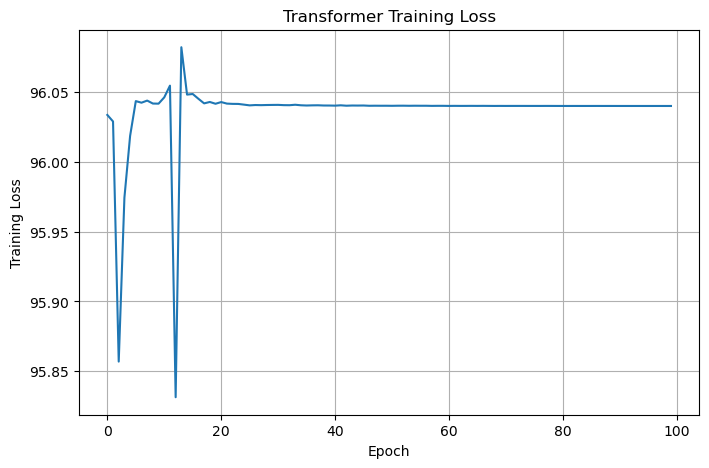

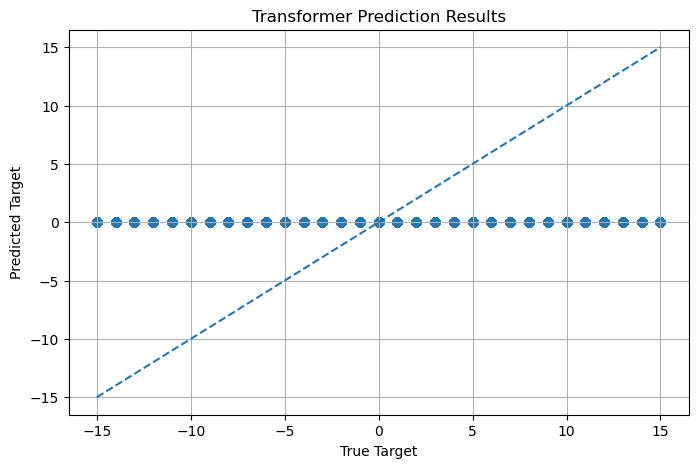

In [12]:

# ========== 10. 可视化训练损失 ==========

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Training Loss")
plt.grid(True)
plt.show()


# ========== 11. 可视化预测结果 ==========

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("Transformer Prediction Results")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid(True)
plt.show()